# PCA 代码实践
我们这里直接使用 python 机器学习工具库 scikit-learn 来给大家演示PCA算法应用（相关知识速查可以查看ShowMeAI文章 [AI建模工具速查|Scikit-learn使用指南](https://www.showmeai.tech/article-detail/108)），sklearn 工具库中与 PCA 相关的类都在 `sklearn.decomposition` 包里，最常用的 PCA 类就是 `sklearn.decomposition.PCA`。

## 1）参数介绍

sklearn 中的 PCA 类使用简单，基本无需调参，一般只需要指定需要降维到的维度，或者降维后的主成分的方差和占原始维度所有特征方差和的比例阈值就可以了。

下面是**sklearn.decomposition.PCA**的主要参数介绍：

*   **n\_components**：PCA 降维后的特征维度数目。
    
*   **whiten**：是否进行白化。所谓白化，就是对降维后的数据的每个特征进行归一化，让方差都为 $1$，默认值是False，即不进行白化。
    
*   **svd\_solver**：奇异值分解 SVD 的方法，有 $4$ 个可以选择的值：{`auto`,`full`,`arpack`,`randomized`}。
    

除上述输入参数，还有两个 PCA 类的成员属性也很重要：

* **explained_variance_**，它代表降维后的各主成分的方差值。
    
* **explained_variance\_ratio_**，它代表降维后的各主成分的方差值占总方差值的比例。

## 2）代码示例

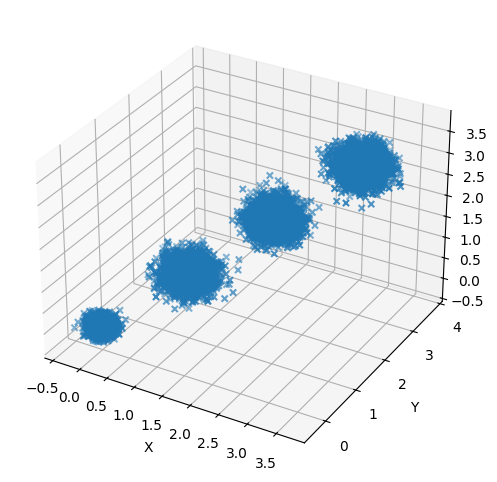

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_blobs

# 生成数据
X, y = make_blobs(n_samples=10000, 
                  n_features=3, 
                  centers=[[3,3,3], [0,0,0], [1,1,1], [2,2,2]], 
                  cluster_std=[0.2, 0.1, 0.2, 0.2], 
                  random_state=9)

# 创建图像
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 散点图绘制
ax.scatter(X[:, 0], X[:, 1], X[:, 2], marker='x')

# 添加标签
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [9]:
from sklearn.decomposition import PCA

# 创建一个 PCA 对象，设置降维后的目标维度为 3
# 虽然原始数据本身就是 3 维的，这里做 PCA 主要是为了观察其主成分的解释能力
pca = PCA(n_components=3)

# 使用训练数据 X 拟合 PCA 模型
pca.fit(X)

# 打印每个主成分所解释的方差比例（即信息保留比例）
# 比如 [0.60, 0.25, 0.15] 表示第一主成分保留了 60% 的方差信息
print(pca.explained_variance_ratio_)

# 打印每个主成分对应的特征值（即方差大小）
# 数值越大说明该主成分方向上的数据分布越“分散”（也即重要性越高）
print(pca.explained_variance_)

[0.98318212 0.00850037 0.00831751]
[3.78521638 0.03272613 0.03202212]


可以看出投影后三个特征维度的方差比例大约为 $98.3\%:0.8\%:0.8\%$。投影后第一个特征占了绝大多数的主成分比例。现在我们来进行降维，从三维降到 $2$ 维，代码如下：

In [15]:
# 创建 PCA 对象，设置保留主成分的数量为 2
# 这表示我们希望把原始的 3 维数据降到 2 维，以便后续可视化或特征压缩
pca = PCA(n_components=2)

# 拟合 PCA 模型，让它根据原始数据 X 找出最能表示数据分布的两个方向（主成分）
pca.fit(X)

# 输出每个主成分的方差解释比例（即每个方向“保留了多少信息”）
# 比如 [0.75, 0.20] 表示这两个主成分合计保留了 95% 的原始信息
print(pca.explained_variance_ratio_)

# 输出每个主成分的特征值（即对应的方差大小）
# 数值越大说明该主成分在该方向上的数据分布越广，信息量越大
print(pca.explained_variance_)

[0.98318212 0.00850037]
[3.78521638 0.03272613]


这个结果其实可以预料，因为上面三个投影后的特征维度的方差分别为：$[3.78521638 \quad 0.03272613]$，投影到二维后选择的肯定是前两个特征，而抛弃第三个特征。为了有个直观的认识，我们看看此时转化后的数据分布，代码如下：

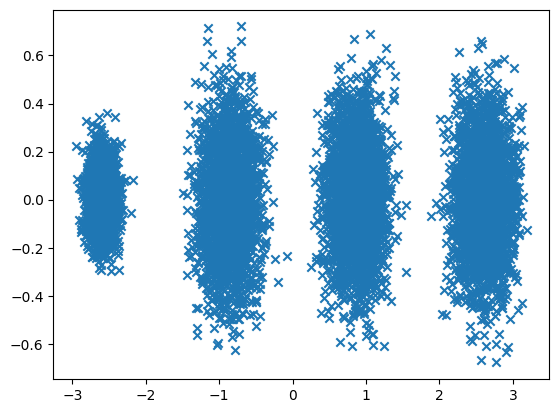

In [11]:
# 将原始数据 X 映射到前两个主成分构成的新二维空间中
# 得到的 X_new 是一个形状为 (10000, 2) 的新特征矩阵
X_new = pca.transform(X)

# 使用 matplotlib 绘制二维散点图
# 每个点表示一个样本在两个主成分方向上的投影（降维后的位置）
plt.scatter(X_new[:, 0], X_new[:, 1], marker='x')

# 显示图像
plt.show()

从上图可以看出，降维后的数据依然清楚可见之前三维图中的 $4$ 个簇。现在我们不直接指定降维的维度，而指定降维后的主成分方差和比例，来试验一下。

In [12]:
# 创建 PCA 对象，n_components 设置为 0.9，表示自动选择最少的主成分个数，使累计解释方差 ≥ 90%
pca = PCA(n_components=0.9)

# 拟合 PCA 模型，根据原始数据 X 计算主成分
pca.fit(X)

# 输出每个保留下来的主成分的解释方差比例
# 表示每个主成分在总方差中所占的比例
print(pca.explained_variance_ratio_)

# 输出每个主成分的特征值（即其方差）
print(pca.explained_variance_)

# 输出保留的主成分数量（会自动选择满足累计解释方差 ≥ 90% 所需的最小数量）
print(pca.n_components_)

[0.98318212]
[3.78521638]
1


可见只有第一个投影特征被保留。这也很好理解，我们的第一个主成分占投影特征的方差比例高达 $98 \%$。只选择这一个特征维度便可以满足 $90 \%$ 的阈值。我们现在选择阈值 $99 \%$ 看看，代码如下：

In [13]:
# 创建 PCA 实例，设定 n_components=0.99
# 这意味着我们希望保留尽可能少的主成分，但能解释原始数据中至少 99% 的方差
pca = PCA(n_components=0.99)

# 拟合 PCA 模型，根据原始数据 X 计算主成分
pca.fit(X)

# 输出每个被保留的主成分的方差解释比例（越高代表越重要）
print(pca.explained_variance_ratio_)

# 输出每个主成分的方差大小（即特征值）
print(pca.explained_variance_)

# 输出最终保留下来的主成分个数
print(pca.n_components_)

[0.98318212 0.00850037]
[3.78521638 0.03272613]
2


这个结果也很好理解，因为我们第一个主成分占了 $98.3 \%$ 的方差比例，第二个主成分占了 $0.8 \%$ 的方差比例，两者一起可以满足我们的阈值。最后我们看看让MLE算法自己选择降维维度的效果，代码如下

In [14]:
# 创建 PCA 实例，使用最大似然估计法自动确定要保留的主成分个数
# svd_solver='full' 表示使用完整奇异值分解，适合中小型数据集
pca = PCA(n_components='mle', svd_solver='full')

# 用数据 X 拟合 PCA 模型，提取主成分
pca.fit(X)

# 输出每个保留主成分解释的方差比例（即每一维主成分保留的信息占比）
print(pca.explained_variance_ratio_)

# 输出每个主成分的方差值（特征值）
print(pca.explained_variance_)

# 输出最终自动确定保留的主成分数量
print(pca.n_components_)

[0.98318212]
[3.78521638]
1


可见由于我们的数据的第一个投影特征的方差占比高达 $98.3 \%$，MLE 算法只保留了我们的第一个特征。